# 压力测试结果可视化

本 notebook 用于根据提供的 CSV 数据，可视化压力测试的结果，主要关注 FPS (每秒帧数) 和点击响应时间随 RPS (每秒请求数) 的变化情况。

## 1. 导入库并加载数据

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_theme(style="whitegrid")

# 加载数据
# 请确保将下面的路径替换为您的 CSV 文件的实际路径
csv_path = './ui-resource-result.csv'
df = pd.read_csv(csv_path)

# 显示数据前几行以确认加载成功
df.head()

,mode,rps,durationSec,submitted,completed,dropped,failed,timedOut,avgReqLatencyMs,p95ReqLatencyMs,...,avgCompletedReqLatencyMs,p95CompletedReqLatencyMs,avgServiceMs,p95ServiceMs,avgTtftMs,p95TtftMs,avgFps,p95FrameMs,avgClickLatencyMs,p95ClickLatencyMs
0,wllama,0,16,16,16,0,0,0,12340.756,15029.6,...,12340.756,15029.6,12334.956,15024.0,530.894,807.6,120.000,33.4,2.900,61.6
1,wLLM,0,16,16,16,0,0,0,7091.406,12880.7,...,7091.406,12880.7,7091.394,12880.7,5591.794,11289.6,120.000,8.8,2.954,5.1
2,wllama,1,16,16,16,0,0,0,12340.756,15029.6,...,12340.756,15029.6,12334.956,15024.0,530.894,807.6,59.762,33.4,27.546,61.6
3,wLLM,1,16,16,16,0,0,0,7091.406,12880.7,...,7091.406,12880.7,7091.394,12880.7,5591.794,11289.6,120.023,8.8,2.954,5.1
4,wllama,2,16,30,5,0,0,25,19612.057,20000.0,...,17672.340,20046.6,17662.620,20034.6,1622.860,2303.8,40.010,41.8,39.541,79.1


## 2. 绘制 FPS vs. RPS 折线图

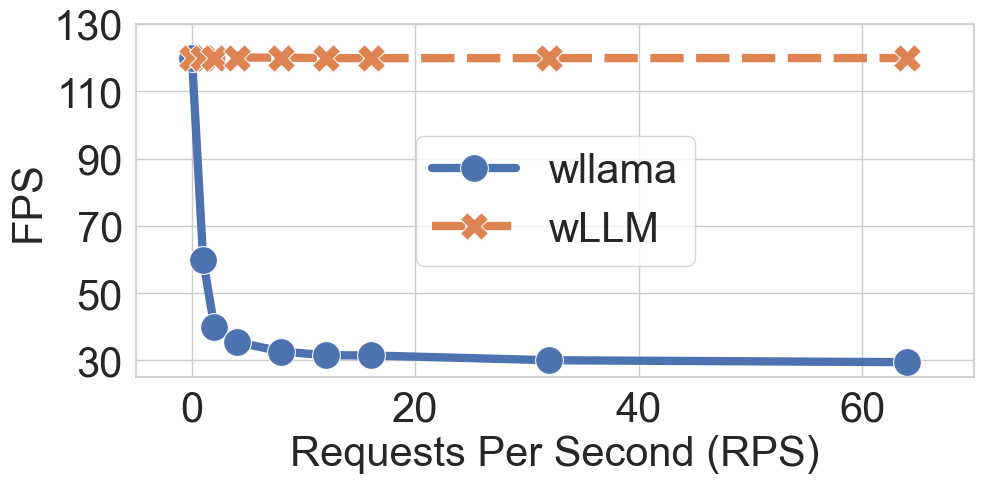

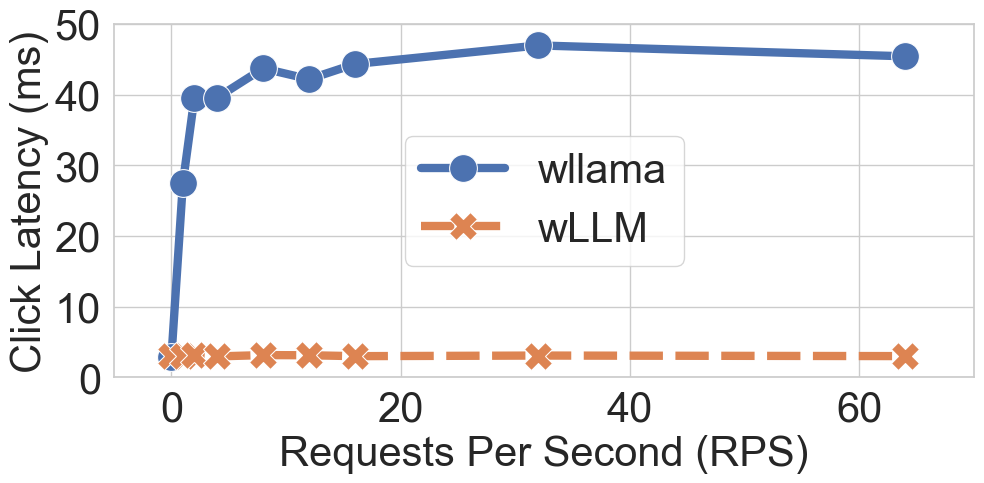

In [37]:
# --- 图 1: FPS vs. RPS ---
plt.figure(figsize=(10, 5))
ax1 = sns.lineplot(data=df, x='rps', y='avgFps', hue='mode', style='mode', markers=True, markersize=20, linewidth=6)
ax1.set_xlabel('Requests Per Second (RPS)', fontsize=30)
ax1.set_ylabel('FPS', fontsize=30)
ax1.set_xlim(-5, 70)
ax1.set_ylim(25, 130)
ax1.set_yticks(range(30, 131, 20))
ax1.tick_params(axis='both', which='major', labelsize=30)
ax1.legend(fontsize=30, loc="center")
ax1.grid(True)

# 保存并显示第一个图表
plt.tight_layout()
plt.savefig("pressure_test_fps.pdf", format='pdf', bbox_inches='tight')
plt.show()


# --- 图 2: Click Response Time vs. RPS ---
plt.figure(figsize=(10, 5))
ax2 = sns.lineplot(data=df, x='rps', y='avgClickLatencyMs', hue='mode', style='mode', markers=True, markersize=20, linewidth=6)
ax2.set_xlabel('Requests Per Second (RPS)', fontsize=30)
ax2.set_ylabel('Click Latency (ms)', fontsize=30)
ax2.set_xlim(-5, 70)
ax2.set_ylim(0, 50)
ax2.set_yticks(range(0, 51, 10))
ax2.tick_params(axis='both', which='major', labelsize=30)
ax2.legend(fontsize=30, loc="center")
ax2.grid(True)

# 保存并显示第二个图表
plt.tight_layout()
plt.savefig("pressure_test_latency.pdf", format='pdf', bbox_inches='tight')
plt.show()

## 3. 从两个 exp1 JSON 生成统一 Latency CDF（flat/tree/webllm）

下面的代码会同时读取两个 JSON 文件：
- 一个包含 `flat + tree` 的 metricLines
- 一个包含 `webllm` 的 metricLines

并分别在各自模式内部按相邻时间戳计算任务 latency，最终将 `flat`、`tree`、`webllm` 三条 CDF 曲线画在同一张图中。

Detected modes: wllama, wLLM, webllm
wllama: count=10021, p50=5258.0ms, p99=5400.0ms
wLLM: count=10021, p50=2783.0ms, p99=2916.0ms
webllm: count=10021, p50=4404.0ms, p99=4554.0ms


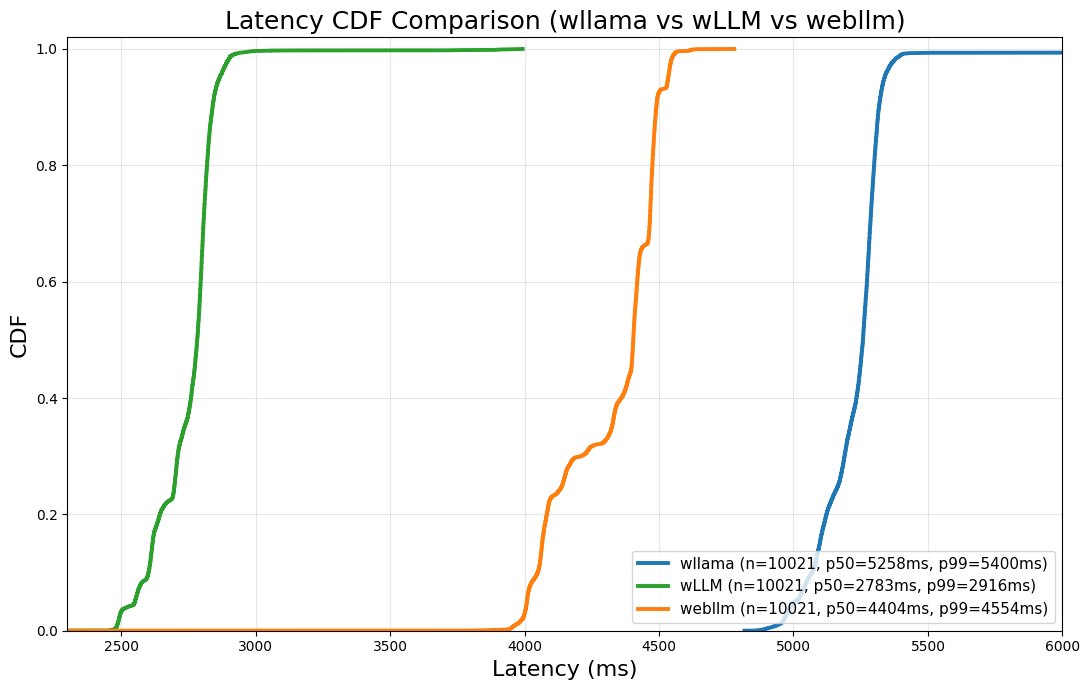

Saved: pressure_test_latency_cdf_flat_tree_webllm.pdf


In [3]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) flat + tree 数据文件
flat_tree_json_path = '/Users/rambo/Downloads/full-hellaswag.json'
# 2) webllm 数据文件
webllm_json_path = '/Users/rambo/Downloads/full-exp1-webllm-hella.json'


def parse_latency_by_mode(json_path, source_name):
    json_file = Path(json_path)
    if not json_file.exists():
        raise FileNotFoundError(f'JSON file not found: {json_file}')

    with json_file.open('r', encoding='utf-8') as f:
        experiment = json.load(f)

    metric_lines = experiment.get('metricLines') or experiment.get('metric_lines') or []
    if not metric_lines:
        raise ValueError(f'{json_file.name} 中没有找到 metricLines 字段，或字段为空')

    timestamp_pattern = re.compile(r'^\[(.*?)\]')
    mode_pattern = re.compile(r'^\[.*?\]\s+\[[^\]/]+/([^\]]+)\]')

    rows = []
    for line in metric_lines:
        ts_match = timestamp_pattern.match(line)
        if ts_match is None:
            continue

        ts = pd.to_datetime(ts_match.group(1), utc=True, errors='coerce')
        if pd.isna(ts):
            continue

        mode_match = mode_pattern.match(line)
        mode = mode_match.group(1).strip().lower() if mode_match else source_name

        if source_name == 'webllm':
            mode = 'webllm'
        elif mode in ('web-llm', 'web_llm'):
            mode = 'webllm'

        rows.append({'timestamp': ts, 'mode': mode})

    metric_df = pd.DataFrame(rows)
    if metric_df.empty:
        raise ValueError(f'{json_file.name} 未能解析出有效时间戳')

    metric_df = metric_df.sort_values(['mode', 'timestamp']).reset_index(drop=True)
    metric_df['latency_ms'] = metric_df.groupby('mode')['timestamp'].diff().dt.total_seconds() * 1000.0

    latency_df = metric_df.dropna(subset=['latency_ms']).copy()
    latency_df = latency_df[latency_df['latency_ms'] >= 0]
    if latency_df.empty:
        raise ValueError(f'{json_file.name} 未得到有效 latency')

    return latency_df


latency_flat_tree = parse_latency_by_mode(flat_tree_json_path, source_name='flat_tree')
latency_webllm = parse_latency_by_mode(webllm_json_path, source_name='webllm')

latency_df = pd.concat([latency_flat_tree, latency_webllm], ignore_index=True)
plot_order = [m for m in ['flat', 'tree', 'webllm'] if m in latency_df['mode'].unique()]

if not plot_order:
    raise ValueError('未检测到可绘制的模式（期望包含 flat/tree/webllm）')

# 展示名映射: 仅影响图例和打印，不影响实际分组
display_name = {
    'flat': 'wllama',
    'tree': 'wLLM',
    'webllm': 'webllm',
}

print('Detected modes:', ', '.join(display_name.get(m, m) for m in plot_order))

palette = {
    'flat': '#1f77b4',
    'tree': '#2ca02c',
    'webllm': '#ff7f0e',
}

plt.figure(figsize=(11, 7))

for mode in plot_order:
    part = latency_df[latency_df['mode'] == mode]
    x = np.sort(part['latency_ms'].to_numpy())
    y = np.arange(1, len(x) + 1) / len(x)

    p50 = part['latency_ms'].quantile(0.5)
    p99 = part['latency_ms'].quantile(0.99)
    mode_label = display_name.get(mode, mode)
    print(f'{mode_label}: count={len(part)}, p50={p50:.1f}ms, p99={p99:.1f}ms')

    plt.plot(
        x,
        y,
        linewidth=2.8,
        color=palette.get(mode),
        label=f'{mode_label} (n={len(part)}, p50={p50:.0f}ms, p99={p99:.0f}ms)',
    )

plt.xlabel('Latency (ms)', fontsize=16)
plt.ylabel('CDF', fontsize=16)
plt.title('Latency CDF Comparison (wllama vs wLLM vs webllm)', fontsize=18)
plt.xlim(2300, 6000)
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()

out_pdf = 'pressure_test_latency_cdf_flat_tree_webllm.pdf'
plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
plt.show()
print(f'Saved: {out_pdf}')